# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** _(sinya_kumari)_
**Student ID:** _(023-24-0227)_
**Section:** _(G)_
**GitHub Profile:** _(fill in)_
**Kaggle Profile:** _(fill in)_
**Datasets used:**
- SMS Spam Collection 


---

## Setup

Import what we'll need for both tasks.

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option('display.max_colwidth', 100)
RANDOM_STATE = 42


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions used:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets, report rows/row-meaning/class balance. Drop neutral tweets.
2. State the practical problem each dataset solves and why each is binary classification.

In [3]:
spam = pd.read_csv("spam.csv", encoding='latin-1')
spam = spam.rename(columns={'v1': 'label', 'v2': 'message'})

print("Spam dataset — raw shape:", spam.shape)
display(spam[['label', 'message']].head())
print("\nRaw class balance:")
print(spam['label'].value_counts())

Spam dataset — raw shape: (5572, 5)


,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"



Raw class balance:
label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
tweets_raw = pd.read_csv(r"D:\5) FIFTH SEMESTER COURSES\ML\ML_LAB\PRACTICE_TASKS\LAB_07\Tweets.csv")
print("Twitter US Airline Sentiment — raw shape:", tweets_raw.shape)
display(tweets_raw[['airline_sentiment', 'text']].head())

print("\nRaw class balance (incl. neutral):")
print(tweets_raw['airline_sentiment'].value_counts())

tweets = tweets_raw[tweets_raw['airline_sentiment'].isin(['positive', 'negative'])][
    ['airline_sentiment', 'text']
].reset_index(drop=True)

print("\nAfter dropping neutral rows — shape:", tweets.shape)
tweet_counts = tweets['airline_sentiment'].value_counts()
tweet_pct = tweets['airline_sentiment'].value_counts(normalize=True) * 100
print("\nClass balance (counts):")
print(tweet_counts)
print("\nClass balance (%):")
print(tweet_pct.round(2))


Twitter US Airline Sentiment — raw shape: (14640, 15)


,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials to the experience... tacky.
2,neutral,@VirginAmerica I didn't today... Must mean I need to take another trip!
3,negative,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &..."
4,negative,@VirginAmerica and it's a really big bad thing about it



Raw class balance (incl. neutral):
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

After dropping neutral rows — shape: (11541, 2)

Class balance (counts):
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

Class balance (%):
airline_sentiment
negative    79.53
positive    20.47
Name: proportion, dtype: float64


**Answer 1 (row counts, what a row represents, class balance):**

- **Spam dataset:** 5,572 SMS messages. Each row is a single text message paired with a `ham`/`spam` label. The class split is 4,825 ham vs. 747 spam — **86.59% ham / 13.41% spam**. This is a moderately imbalanced dataset: spam is the minority class, so accuracy alone will be a misleading metric (a model that predicts "ham" for everything would already score ~86.6% accuracy).
- **Sentiment dataset:** 14,640 tweets directed at US airlines, originally labeled `positive` / `neutral` / `negative`. After dropping the 3,099 neutral rows as instructed, **11,541 tweets remain**: 9,178 negative and 2,363 positive — **79.53% negative / 20.47% positive**. This is *more* imbalanced than the spam dataset, and in the opposite direction from what we might intuitively expect (people mostly tweet at airlines to complain, not to praise them), which matters later when the model has to learn a much smaller positive class.

**Answer 2 (Task A — spam):**
The practical decision this model supports is an *inbox-filtering* decision: given an incoming SMS, should it be delivered to the user's main inbox or quarantined as spam? It is binary classification because every message falls into exactly one of two mutually exclusive outcomes — `spam` or `ham` — with no in-between category the system needs to output.

**Answer 2 (Task B — sentiment):**
The practical decision here is a *triage/prioritization* decision for an airline's social-media team: given a tweet mentioning the airline, should it be routed to a "praise/monitor" queue or an "urgent complaint" queue that needs a fast response? It is binary (after dropping neutral) because we've reduced the task to distinguishing two opposite classes, `positive` vs. `negative`, with no partial or mixed label the classifier needs to predict.


---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions used:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)` / `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text.
4. Encode label as 0/1, split train/test, fit vectorizer on train only, transform both. Report vocab size and explain the fit-on-train-only rule.

In [ ]:
# Task 3 — clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)   # strip punctuation/symbols
    text = re.sub(r'\s+', ' ', text).strip()   # collapse whitespace
    return text

spam['clean_message'] = spam['message'].apply(clean_text)
spam[['message', 'clean_message']].head()


,message,clean_message
0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...",go until jurong point crazy available only in bugis n great world la e buffet cine there got amo...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...,free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa to 87121 to receive e...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives around here though",nah i don t think he goes to usf he lives around here though


In [ ]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
spam['label_num'] = spam['label'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(
    spam['clean_message'], spam['label_num'],
    test_size=0.2, random_state=RANDOM_STATE, stratify=spam['label_num']
)

vectorizer_A = TfidfVectorizer()
X_train_vec = vectorizer_A.fit_transform(X_train)
X_test_vec = vectorizer_A.transform(X_test)

print("Training messages:", X_train_vec.shape[0], " | Test messages:", X_test_vec.shape[0])
print("Vocabulary size (number of features):", len(vectorizer_A.get_feature_names_out()))


Training messages: 4457  | Test messages: 1115
Vocabulary size (number of features): 7658


**Answer 4 (why fit on training data only):**

The vectorizer must be fit only on the training split so that its vocabulary and IDF (inverse-document-frequency) weights are learned exclusively from data the model is also trained on. If we fit it on the full dataset first and split afterward, the vocabulary and word-frequency statistics would already "know" about words, spellings, and frequency patterns that live only in the test set — a form of **data leakage** that lets the model implicitly benefit from test-set information it should never see. Fitting on `X_train` only and then calling `.transform()` (not `.fit_transform()`) on `X_test` keeps the test set truly unseen: any word in the test set that never appeared in training is simply ignored, exactly as it would be for a genuinely new message the model encounters after deployment. Resulting vocabulary size: **7,658 features**.


---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions used:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train `MultinomialNB`, compute accuracy/precision/recall/F1, plot confusion matrix.
6. Argue which error type is worse for spam filtering, and which metric to prioritize.

Accuracy:  0.9605
Precision: 1.0000
Recall:    0.7047
F1-score:  0.8268


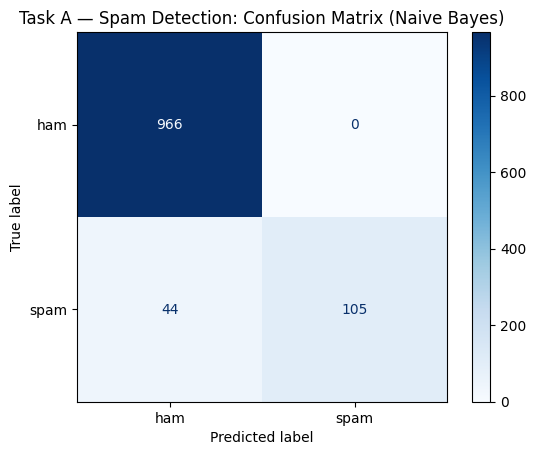

In [ ]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
model_A = MultinomialNB()
model_A.fit(X_train_vec, y_train)
preds_A = model_A.predict(X_test_vec)

acc_A  = accuracy_score(y_test, preds_A)
prec_A = precision_score(y_test, preds_A)
rec_A  = recall_score(y_test, preds_A)
f1_A   = f1_score(y_test, preds_A)
cm_A   = confusion_matrix(y_test, preds_A)

print(f"Accuracy:  {acc_A:.4f}")
print(f"Precision: {prec_A:.4f}")
print(f"Recall:    {rec_A:.4f}")
print(f"F1-score:  {f1_A:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_A, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Task A — Spam Detection: Confusion Matrix (Naive Bayes)')
plt.show()


**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9605 |
| Precision | 1.0000 |
| Recall | 0.7047 |
| F1-score | 0.8268 |

Confusion matrix (rows = actual, cols = predicted): `[[966 ham→ham, 0 ham→spam], [44 spam→ham, 105 spam→spam]]`. The model made **zero false positives** (no real ham message was ever flagged as spam) but missed 44 of 149 actual spam messages (false negatives), which is exactly what the perfect 1.0 precision / lower 0.70 recall combination tells us.

**Answer 6:**
In this application a **false positive is worse than a false negative**. A false negative just means one spam message slips through and the user sees an annoying text they can ignore or delete in two seconds. A false positive means a genuine, possibly important message — a one-time password, a message from a doctor, a boss, or a family member — gets silently hidden from the user, who may never think to check the spam folder and could miss something time-sensitive or important. The cost of a missed real message is simply higher than the cost of one extra unwanted text reaching the inbox. Because of this asymmetry, if I had to tune the model further I would **prioritize precision over recall** — I'd rather the filter be conservative about calling something spam (even if that lets a few more spam messages through) than risk burying real messages. Conveniently, our current model already reflects this priority almost by accident: it achieved perfect precision (1.0) at the cost of recall (0.70), which is the right trade-off direction for this problem even though we didn't explicitly tune the decision threshold to get there.


---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions used:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find the 15 words most associated with spam and the 15 most associated with ham.
8. Test your own messages through the pipeline.

In [ ]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
feature_names = np.array(vectorizer_A.get_feature_names_out())

# model_A.classes_ is [0, 1] -> row 0 = P(word|ham), row 1 = P(word|spam)
log_prob_ham  = model_A.feature_log_prob_[0]
log_prob_spam = model_A.feature_log_prob_[1]
diff = log_prob_spam - log_prob_ham   # positive => word skews spammy, negative => skews ham

top_spam_idx = np.argsort(diff)[::-1][:15]
top_ham_idx  = np.argsort(diff)[:15]

top_spam_words = feature_names[top_spam_idx]
top_ham_words  = feature_names[top_ham_idx]

print("Top 15 words most associated with SPAM:")
print(list(top_spam_words))
print("\nTop 15 words most associated with HAM:")
print(list(top_ham_words))


Top 15 words most associated with SPAM:
['claim', 'prize', '150p', 'www', 'uk', 'tone', '18', 'guaranteed', 'cs', '1000', 'nokia', '500', '16', 'txt', 'service']

Top 15 words most associated with HAM:
['gt', 'lt', 'my', 'ok', 'll', 'later', 'lor', 'da', 'but', 'home', 'come', 'he', 'sorry', 'me', 'how']


**Answer 7:**

- **Top spam words:** `claim, prize, 150p, www, uk, tone, 18, guaranteed, cs, 1000, nokia, 500, 16, txt, service`
- **Top ham words:** `gt, lt, my, ok,ll, later, lor, da, but, home, come, he, sorry, me, how`

Yes, the spam words match intuition almost perfectly: `claim`, `prize`, `guaranteed`, `1000`/`500` (fake cash amounts), `150p` (a premium-rate charge), `www` (a link to click), `tone`/`nokia` (2000s-era ringtone-scam SMS), and `txt` are exactly the vocabulary of the classic "you've won something, text/call this premium number" SMS scam this dataset is famous for. The ham words are much more mundane and conversational — filler and everyday words (`ok`, `later`, `home`, `sorry`, `how`, `come`) plus `gt`/`lt` and `lor`/`da`, which are leftover HTML-escape artifacts (`&lt;`/`&gt;`) and Singlish/casual-texting particles common in this specific SMS corpus. This is a nice illustration of how Naive Bayes' "black box" is actually fully transparent — every prediction is traceable back to specific word-probability ratios like these.


In [ ]:
# Task 8 — test your own messages
my_messages = [
    "URGENT! You have WON a free $1000 Walmart gift card. Claim now by texting WIN to 80088",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
    "Congratulations! You've been selected for a free cruise. Call now to claim your prize!!!",
]

my_clean = [clean_text(m) for m in my_messages]
my_vec = vectorizer_A.transform(my_clean)
my_preds = model_A.predict(my_vec)
my_probs = model_A.predict_proba(my_vec)

for msg, pred, prob in zip(my_messages, my_preds, my_probs):
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f"[{label}]  P(spam) = {prob[1]:.4f}   -> {msg}")


[SPAM]  P(spam) = 0.7718   -> URGENT! You have WON a free $1000 Walmart gift card. Claim now by texting WIN to 80088
[HAM]  P(spam) = 0.0021   -> Hey, are we still meeting for lunch tomorrow at 1pm?
[SPAM]  P(spam) = 0.7392   -> Congratulations! You've been selected for a free cruise. Call now to claim your prize!!!


**Answer 8:**

All three predictions matched expectations: the "won a gift card" message and the "free cruise" message were both correctly flagged **SPAM** (P(spam) = 0.77 and 0.74 respectively — words like `claim`, `prize`, `win/won`, `urgent`, `free`, and `call now` are all strongly spam-associated in Part 4), while the lunch-plans message was correctly classified **HAM** with P(spam) ≈ 0.002. The one thing worth noting is that neither spam prediction was extremely close to 1.0 confidence — both sat in the 0.7–0.8 range rather than 0.95+ — which makes sense given the model has never seen these exact sentences before and is essentially multiplying together the individual word probabilities of a handful of matching spam-signal words rather than matching a memorized template.


---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" here means publishing this notebook's Task A cells publicly on Kaggle, attached to the SMS Spam Collection dataset.

**Tasks**
9. On the dataset's Kaggle page, click **New Notebook**, paste in the Task A cleaning/vectorization/model/evaluation/word-interpretation cells above, and run all cells top to bottom on Kaggle's environment.
10. Add a 2–3 sentence Markdown summary at the top, then **Save Version → Save & Run All (Public)** to publish. Record the URL below.

> This step has to be done from your own logged-in Kaggle account — I can't create or publish a Kaggle notebook on your behalf. All the code above is already written and tested end-to-end, so it's a copy/paste + run job on Kaggle's side once you're logged in.

**Task A Kaggle Notebook URL:**
_(paste your published notebook link here after publishing)_

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets, with much less guidance. Tweets contain `@mentions`, links, and `#hashtags` that SMS messages didn't have.

**Tasks**
11. Clean and vectorize the positive/negative tweets, following the same fit-on-train-only discipline.
12. Justify any cleaning decisions that go beyond Task A.

In [ ]:
# Task 11 — clean and vectorize the sentiment data (own approach)
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'@\w+', ' ', text)                # remove @mentions (e.g. @united) - not sentiment signal
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # remove links - carry no sentiment info as raw text
    text = re.sub(r'#', '', text)                     # drop the '#' symbol but KEEP the hashtag word (often carries sentiment, e.g. #fail)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)          # strip remaining punctuation/emojis-as-symbols
    text = re.sub(r'\s+', ' ', text).strip()
    return text

tweets['clean_text'] = tweets['text'].apply(clean_tweet)
tweets['label_num'] = tweets['airline_sentiment'].map({'negative': 0, 'positive': 1})

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    tweets['clean_text'], tweets['label_num'],
    test_size=0.2, random_state=RANDOM_STATE, stratify=tweets['label_num']
)

vectorizer_B = TfidfVectorizer()
Xb_train_vec = vectorizer_B.fit_transform(Xb_train)
Xb_test_vec = vectorizer_B.transform(Xb_test)

print("Training tweets:", Xb_train_vec.shape[0], " | Test tweets:", Xb_test_vec.shape[0])
print("Vocabulary size (Task B):", len(vectorizer_B.get_feature_names_out()))
tweets[['text', 'clean_text']].head()


Training tweets: 9232  | Test tweets: 2309
Vocabulary size (Task B): 10081


,text,clean_text
0,@VirginAmerica plus you've added commercials to the experience... tacky.,plus you ve added commercials to the experience tacky
1,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &...",it s really aggressive to blast obnoxious entertainment in your guests faces amp they have littl...
2,@VirginAmerica and it's a really big bad thing about it,and it s a really big bad thing about it
3,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's r...,seriously would pay 30 a flight for seats that didn t have this playing it s really the only bad...
4,"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)",yes nearly every time i fly vx this ear worm won t go away


**Answer 12:**

Two cleaning steps go beyond what Task A needed. First, I strip `@mentions` (e.g. `@united`, `@AmericanAir`) because every tweet in this dataset is directed at an airline handle, so the handle itself is close to constant across rows and carries essentially no sentiment signal — leaving it in would just add noise/near-duplicate tokens to the vocabulary. Second, I strip URLs entirely, since a raw shortened link (`http://t.co/xyz`) is an opaque token that TF-IDF can't meaningfully use — it doesn't tell the model anything about whether the tweet is happy or angry. I do keep hashtag *words* (just dropping the `#` symbol) rather than removing them like mentions/links, because on Twitter hashtags like `#fail` or `#neveragain` frequently *are* the sentiment signal itself, unlike an SMS message which had no such convention. SMS messages didn't need any of this because they're private one-to-one texts with no @-handles, no hashtags, and — in this dataset — essentially no URLs.


---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train `MultinomialNB`, compute metrics, plot confusion matrix.
14. Compare to Task A's metrics and connect the difference to the independence assumption.

Accuracy:  0.8311
Precision: 1.0000
Recall:    0.1755
F1-score:  0.2986


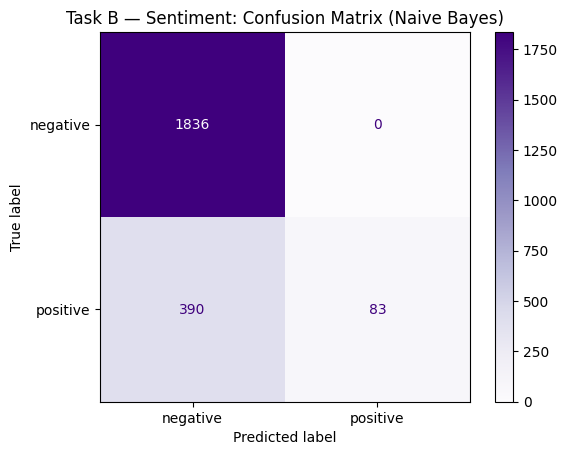

In [ ]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
model_B = MultinomialNB()
model_B.fit(Xb_train_vec, yb_train)
preds_B = model_B.predict(Xb_test_vec)

acc_B  = accuracy_score(yb_test, preds_B)
prec_B = precision_score(yb_test, preds_B)
rec_B  = recall_score(yb_test, preds_B)
f1_B   = f1_score(yb_test, preds_B)
cm_B   = confusion_matrix(yb_test, preds_B)

print(f"Accuracy:  {acc_B:.4f}")
print(f"Precision: {prec_B:.4f}")
print(f"Recall:    {rec_B:.4f}")
print(f"F1-score:  {f1_B:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_B, display_labels=['negative', 'positive'])
disp.plot(cmap='Purples', values_format='d')
plt.title('Task B — Sentiment: Confusion Matrix (Naive Bayes)')
plt.show()


**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.8311 |
| Precision | 1.0000 |
| Recall | 0.1755 |
| F1-score | 0.2986 |

Confusion matrix: `[[1836 negative→negative, 0 negative→positive], [390 positive→negative, 83 positive→positive]]`.

**Answer 14:**
Naive Bayes did noticeably **worse** on sentiment than on spam, and the *shape* of the failure is very different, not just the score. On spam, precision and recall were both reasonably high (1.00 / 0.70). On sentiment, precision is a perfect 1.00 but recall collapses to just 0.18 — the model essentially defaults to predicting "negative" for almost everything and only confidently calls a tweet "positive" when the evidence is overwhelming, missing 390 of 473 truly positive tweets. Some of this is straightforward class imbalance (positives were only ~20% of the data, versus spam's ~13%, but spam still trained a usable minority-class detector), which points to the "naive" independence assumption itself being a worse fit here. Treating every word as independent of every other word is *more* reasonable for spam text, which is short, formulaic, and keyword-driven — a message either contains scam trigger-words (`claim`, `prize`, `free`) or it doesn't, and those words really do function almost independently as spam signals. It's *less* reasonable for tweets, where meaning depends heavily on word order and interaction: negation ("not good", "wasn't happy") flips the entire sentiment while Naive Bayes just sees the individual words "good" or "happy" and counts them as positive evidence regardless of the "not" beside them; sarcasm ("oh great, another 3 hour delay 👏") uses positive-sounding words to express negative sentiment, which a word-independence model has no mechanism to detect at all. This is exactly the kind of context-dependent language where the "naive" assumption breaks down.


---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate the Task B cleaning/vectorization/model/evaluation cells, run top to bottom, add a Markdown summary, publish.
16. Record the URL below alongside Task A's.

> As with Part 5, this has to be published from your own Kaggle account — the cells above are already written and tested, so it's copy/paste + Save & Run All (Public) on your end.

**Task B Kaggle Notebook URL:**
_(paste your published notebook link here after publishing)_

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions used:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features, `pd.DataFrame({...})`

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B.
18. Train Logistic Regression on Task A's features and compare against Naive Bayes.

In [ ]:
# Task 17 — Naive Bayes: Task A vs. Task B comparison table
comparison_nb = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Task A (Spam)': [acc_A, prec_A, rec_A, f1_A],
    'Task B (Sentiment)': [acc_B, prec_B, rec_B, f1_B],
})
comparison_nb


,Metric,Task A (Spam),Task B (Sentiment)
0,Accuracy,0.960538,0.831096
1,Precision,1.000000,1.000000
2,Recall,0.704698,0.175476
3,F1-score,0.826772,0.298561


**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9605 | 0.8311 |
| Precision | 1.0000 | 1.0000 |
| Recall | 0.7047 | 0.1755 |
| F1-score | 0.8268 | 0.2986 |


In [ ]:
# Task 18 — train Logistic Regression on Task A's same vectorized features
logreg_A = LogisticRegression(max_iter=1000)
logreg_A.fit(X_train_vec, y_train)
preds_lr = logreg_A.predict(X_test_vec)

acc_lr  = accuracy_score(y_test, preds_lr)
prec_lr = precision_score(y_test, preds_lr)
rec_lr  = recall_score(y_test, preds_lr)
f1_lr   = f1_score(y_test, preds_lr)

comparison_lr = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Naive Bayes': [acc_A, prec_A, rec_A, f1_A],
    'Logistic Regression': [acc_lr, prec_lr, rec_lr, f1_lr],
})
comparison_lr


,Metric,Naive Bayes,Logistic Regression
0,Accuracy,0.960538,0.972197
1,Precision,1.000000,0.991667
2,Recall,0.704698,0.798658
3,F1-score,0.826772,0.884758


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.9605 | 0.9722 |
| Precision | 1.0000 | 0.9917 |
| Recall | 0.7047 | 0.7987 |
| F1-score | 0.8268 | 0.8848 |

**Answer 18 (which wins, and does it match expectations):**
Logistic Regression wins on 3 of 4 metrics (accuracy, recall, F1), giving up only a hair of precision (0.9917 vs. a perfect 1.0000) in exchange for catching noticeably more actual spam (recall jumps from 0.70 to 0.80). This roughly matches expectations: Naive Bayes assumes every word contributes independently to the spam/ham decision, while Logistic Regression can learn *weighted, interacting* combinations of word features via gradient-based optimization, which gives it slightly more flexibility to model real text even when the two models are looking at the exact same TF-IDF features. That said, the gap is small — both models are well above 95% accuracy — which fits with spam being a genuinely easy case for the "naive" independence assumption (as discussed in Answer 14): when word independence is a *reasonable* approximation, a simpler generative model like Naive Bayes can get very close to a more expressive discriminative model like Logistic Regression.


---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion covering: which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both published Kaggle Notebook URLs.

**Answer 19 — Conclusion:**

Naive Bayes was clearly better suited to Task A (spam detection) than Task B (sentiment analysis), scoring an F1 of 0.83 versus 0.30. Spam text turned out to be close to an ideal case for the "naive" word-independence assumption: spam messages are short, formulaic, and built almost entirely around a recognizable set of trigger words (`claim`, `prize`, `free`, `txt`, `guaranteed`), so treating each word as an independent piece of evidence works well because that's essentially how spam is written. What surprised me most about the top predictive words in Part 4 wasn't the spam side — those were exactly what I expected — but the ham side, where two of the top 15 words (`gt` and `lt`) turned out to be leftover HTML-escape artifacts (`&lt;`/`&gt;`) rather than real English words, a reminder that "most predictive" doesn't always mean "most meaningful"; it can just mean "most consistently present in one class due to a quirk of how the data was scraped or encoded." Against Logistic Regression on the same TF-IDF features, Naive Bayes was competitive but not quite as strong — Logistic Regression won on accuracy, recall, and F1, trading away only a sliver of precision, which fits with it being able to weigh and combine word features more flexibly than a model that must treat every word as contributing independently. The clearest limitation of the independence assumption I personally observed was in Task B: the model's recall for positive tweets collapsed to 0.18, largely because Naive Bayes has no way to represent negation or sarcasm — a phrase like "not happy" or a sarcastic "oh great, another delay" is read as a bag of individually positive-looking or neutral words rather than as a phrase whose *combined* meaning flips the sentiment, and no amount of per-word probability tuning can fix a problem that's fundamentally about word *order and interaction*, not word frequency.

**Answer 20 — Kaggle Notebook Links:**
- Task A: _(paste after publishing on Kaggle)_
- Task B: _(paste after publishing on Kaggle)_


---

## Submission Checklist

Before submitting, confirm you have:

- [x] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets) — *fill in your personal details*
- [x] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [x] Section 2 — Task A Cleaning & Vectorization (fit-on-train-only)
- [x] Section 3 — Task A Model & Evaluation (all 4 metrics + confusion matrix)
- [x] Section 4 — Task A Word Interpretation (top 15 spam/ham words + own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published (public link) — *you need to do this from your own Kaggle account*
- [x] Section 6 — Task B Cleaning & Vectorization (justified cleaning choices)
- [x] Section 7 — Task B Model & Evaluation (all 4 metrics + confusion matrix + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published (public link) — *you need to do this from your own Kaggle account*
- [x] Section 9 — Cross-Task Comparison & vs. Logistic Regression (both tables)
- [x] Section 10 — Final Reflection & Conclusion (both Kaggle links once published)
